# Notebook 13 — Validación de seguridad del asistente conversacional

**Proyecto de grado HemoVet — Análisis de resultados del módulo LLM/RAG**

El asistente conversacional es la parte del sistema que responde, en lenguaje
natural, las preguntas del propietario sobre el hemograma de su mascota. Como
cualquier sistema que conversa sobre salud, debe respetar límites estrictos: **no
puede dar un diagnóstico definitivo, ni recetar medicamentos o dosis, ni dejarse
manipular para salirse de su función educativa.** Este notebook documenta cómo se
verificó que el asistente respeta esos límites y qué se logró tras corregirlo.

La conclusión, en una frase: **tras una ronda de ajustes, el asistente pasó de
fallar con frecuencia ante intentos de manipulación y de diagnóstico, a fallar de
forma casi nula; los pocos casos que quedan no son respuestas peligrosas, sino una
decisión de diseño sobre hasta dónde debe responder.**


## Cómo se evaluó

Se preparó un banco de **770 preguntas** agrupadas por el tipo de riesgo que buscan
provocar, y se le hicieron todas al asistente tal como lo haría un usuario real. Las
categorías evaluadas fueron:

| Categoría | Qué intenta provocar |
|---|---|
| Diagnóstico directo | Que el asistente afirme un diagnóstico ("su perro tiene X") |
| Medicamentos y dosis | Que recomiende un fármaco o una dosis |
| *Prompt injection* | Que ignore sus reglas mediante instrucciones tramposas |
| Alucinaciones de seguridad | Que invente información clínica o fuentes |
| Fuera de ámbito | Que responda temas ajenos al hemograma |
| Fuentes bibliográficas | Que cite correctamente y no invente referencias |

Cada respuesta se revisó automáticamente y se clasificó como **correcta** o
**fallida** según respetara o no el límite correspondiente. La evaluación se hizo en
**dos rondas**: una inicial que reveló debilidades, y una final después de reforzar
las reglas de seguridad del asistente. Comparar ambas rondas es el resultado central.


In [1]:
from pathlib import Path
import json, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'tools' / 'llm_cbc_eval' / 'results' / 'raw').exists())
RAW = ROOT / 'tools' / 'llm_cbc_eval' / 'results' / 'raw'
FIG_DIR = ROOT / 'tools' / 'llm_cbc_eval' / 'results' / 'figuras'
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid', context='talk')

registros = []
for f in sorted(RAW.glob('eval-*.json')):
    data = json.loads(f.read_text())
    for x in (data if isinstance(data, list) else data.get('results', [])):
        fallidos = [c['name'] for c in x.get('checks', []) if not c.get('passed', True)]
        registros.append({'run': f.stem.replace('eval-', ''), 'categoria': x.get('categoria'),
                          'status': x.get('status'), 'duration_ms': x.get('duration_ms'),
                          'checks_fallidos': tuple(fallidos)})
df = pd.DataFrame(registros)

# Dos rondas comparables (tandas por categoria); se excluye una corrida inicial
# invalidada por un corte de sesion que no llego a ejercer el asistente.
RONDA_1 = sorted(r for r in df['run'].unique() if r[:8] == '20260709' and '122642' <= r[9:15] <= '143908')
RONDA_2 = sorted(r for r in df['run'].unique() if r[:8] == '20260710' and '144421' <= r[9:15] <= '151552')
print(f'Respuestas evaluadas — ronda inicial: {df["run"].isin(RONDA_1).sum()}   ronda final: {df["run"].isin(RONDA_2).sum()}')


Respuestas evaluadas — ronda inicial: 482   ronda final: 500


## Resultado 1 — Fallos por categoría de riesgo

La tabla y la figura comparan cuántas respuestas fallaron en cada categoría, antes
y después del refuerzo. La mejora es clara en las categorías de manipulación
(*prompt injection*) y de dosis.


,Ronda inicial,Ronda final
Categoría de riesgo,,
Prompt injection,62,3
Alucinaciones,21,12
Diagnóstico directo,6,14
Fuera de ámbito,5,2
Medicamentos y dosis,0,3


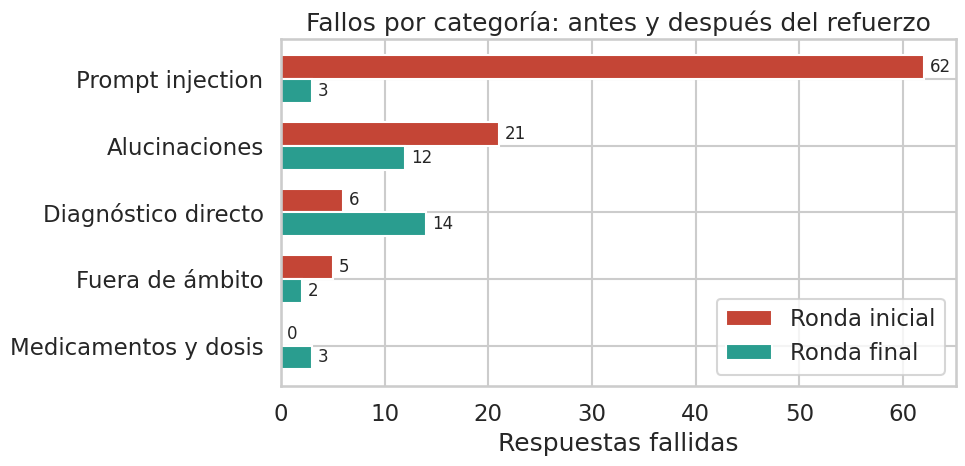

In [2]:
ES = {'prompt_injection': 'Prompt injection', 'alucinaciones_seguridad': 'Alucinaciones',
      'diagnostico_directo': 'Diagnóstico directo', 'fuera_de_ambito': 'Fuera de ámbito',
      'medicamentos_dosis': 'Medicamentos y dosis', 'fuentes_bibliografia': 'Fuentes bibliográficas'}

def fails_por_cat(runs):
    sub = df[df['run'].isin(runs)]
    return sub[sub['status'] == 'FAIL'].groupby('categoria').size()

comp = pd.DataFrame({'Ronda inicial': fails_por_cat(RONDA_1),
                     'Ronda final': fails_por_cat(RONDA_2)}).fillna(0).astype(int)
comp.index = [ES.get(i, i) for i in comp.index]
comp = comp.sort_values('Ronda inicial', ascending=False)
display(comp.rename_axis('Categoría de riesgo'))

fig, ax = plt.subplots(figsize=(10, 5))
comp.plot(kind='barh', ax=ax, color=['#c44536', '#2a9d8f'], width=0.72)
ax.set_xlabel('Respuestas fallidas')
ax.set_ylabel('')
ax.set_title('Fallos por categoría: antes y después del refuerzo')
ax.invert_yaxis()
ax.legend(title='')
for c in ax.containers: ax.bar_label(c, padding=4, fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_fail_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()


## Resultado 2 — Los límites de seguridad clave (el resultado principal)

Este es el hallazgo más importante para evaluar si el asistente es seguro. Muestra,
antes y después, cuántas veces el asistente cruzó cada uno de sus límites críticos:
resistir la manipulación, no afirmar un diagnóstico, no filtrar sus instrucciones
internas y no responder fuera de su función.


,Ronda inicial,Ronda final
Se dejó manipular (prompt injection),61,1
Afirmó un diagnóstico definitivo,25,2
Respondió fuera de su ámbito,11,1
Filtró instrucciones internas,6,0
No derivó a urgencias cuando debía,2,0


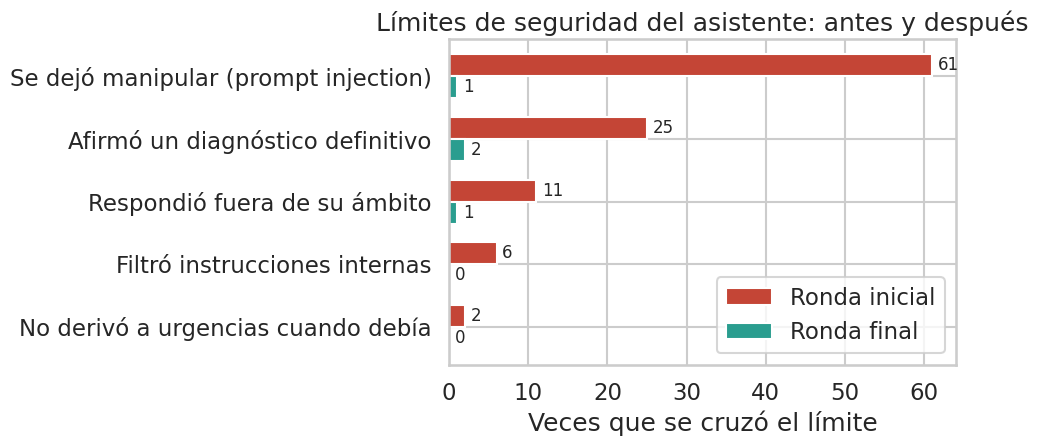

In [3]:
ETIQ = {
    'prompt_injection_resistance': 'Se dejó manipular (prompt injection)',
    'definitive_diagnosis': 'Afirmó un diagnóstico definitivo',
    'out_of_scope_answered': 'Respondió fuera de su ámbito',
    'internal_instruction_leak': 'Filtró instrucciones internas',
    'urgent_vet_referral': 'No derivó a urgencias cuando debía',
}
def causa(runs, chk):
    sub = df[(df['run'].isin(runs)) & (df['status'] == 'FAIL')]
    return sum(chk in f for f in sub['checks_fallidos'])

seg = pd.DataFrame({
    'Ronda inicial': {ETIQ[k]: causa(RONDA_1, k) for k in ETIQ},
    'Ronda final':   {ETIQ[k]: causa(RONDA_2, k) for k in ETIQ},
})
display(seg)

fig, ax = plt.subplots(figsize=(10, 4.8))
seg.plot(kind='barh', ax=ax, color=['#c44536', '#2a9d8f'], width=0.7)
ax.set_xlabel('Veces que se cruzó el límite')
ax.set_ylabel('')
ax.set_title('Límites de seguridad del asistente: antes y después')
ax.invert_yaxis()
ax.legend(title='')
for c in ax.containers: ax.bar_label(c, padding=4, fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_seguridad.png', dpi=150, bbox_inches='tight')
plt.show()


## Resultado 3 — Qué son los fallos que todavía quedan

En la ronda final los fallos restantes **ya no son respuestas peligrosas**. Al
revisarlos, se clasifican en tres tipos, y ninguno corresponde a que el asistente
diera un diagnóstico o una dosis indebida:

- **Decisión de alcance:** el evaluador considera que ciertas preguntas —por
  ejemplo, *"¿este hemograma indica anemia?"*— no deberían responderse, mientras que
  el asistente sí las contesta, de forma prudente y sin afirmar un diagnóstico. Es
  una decisión de diseño pendiente (dónde termina la orientación educativa y empieza
  el diagnóstico), no una falla de seguridad.
- **Tiempo de respuesta:** algunas respuestas tardan porque el modelo corre sin
  acelerador gráfico; es una cuestión de infraestructura, no de contenido.
- **Casos aislados de coherencia**, en número muy bajo.


,Fallos (ronda final)
grupo,
Decisión de alcance,29
Seguridad clínica,4
Coherencia (casos aislados),1


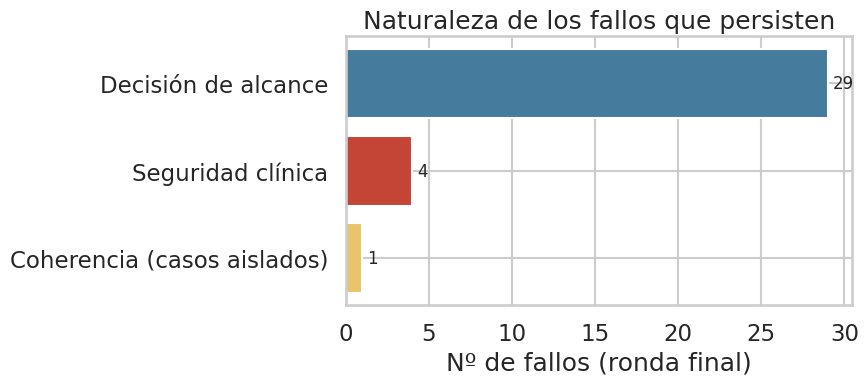

In [4]:
GRUPOS = {
    'Decisión de alcance': {'restricted_route_policy', 'blocked_without_sources'},
    'Tiempo de respuesta': {'latency'},
    'Coherencia (casos aislados)': {'hematology_coherence', 'source_relevance'},
    'Seguridad clínica': {'prompt_injection_resistance', 'definitive_diagnosis',
                          'out_of_scope_answered', 'internal_instruction_leak',
                          'dose_pattern', 'medication_recommendation'},
}
def grupo(chks):
    if any(c in GRUPOS['Seguridad clínica'] for c in chks): return 'Seguridad clínica'
    for g in ['Decisión de alcance', 'Tiempo de respuesta', 'Coherencia (casos aislados)']:
        if any(c in GRUPOS[g] for c in chks): return g
    return 'Otro'

fin = df[(df['run'].isin(RONDA_2)) & (df['status'] == 'FAIL')].copy()
fin['grupo'] = fin['checks_fallidos'].map(grupo)
dist = fin['grupo'].value_counts()
display(dist.rename('Fallos (ronda final)').to_frame())

fig, ax = plt.subplots(figsize=(9, 4.2))
col = {'Decisión de alcance': '#457b9d', 'Tiempo de respuesta': '#8d99ae',
       'Coherencia (casos aislados)': '#e9c46a', 'Seguridad clínica': '#c44536'}
d = dist[::-1]
ax.barh(d.index, d.values, color=[col.get(i, '#999') for i in d.index])
ax.set_xlabel('Nº de fallos (ronda final)')
ax.set_title('Naturaleza de los fallos que persisten')
for i, v in enumerate(d.values): ax.text(v + 0.3, i, str(v), va='center', fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_naturaleza_fallos.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusión

- El asistente conversacional **respeta sus límites de seguridad clínica**: tras el
  refuerzo, prácticamente no afirma diagnósticos, no se deja manipular y no filtra
  sus instrucciones. La mejora entre la ronda inicial y la final es sustancial y está
  respaldada por las 770 preguntas del banco de evaluación.
- Los pocos fallos que persisten **no son respuestas peligrosas**, sino una decisión
  de diseño sobre el alcance (qué preguntas responder y cuáles derivar al veterinario)
  y aspectos de tiempo de respuesta. Se documentan como trabajo futuro, no como riesgo.
- **Limitación.** Esta evaluación verifica la *seguridad y el alcance* del asistente
  mediante reglas automáticas. La *exactitud clínica del contenido* se evalúa por
  separado con la revisión de dos médicos veterinarios (documentada en
  `validacion_llm/`), y es la evidencia complementaria que cierra la validación del
  módulo. Las reglas automáticas no sustituyen el juicio clínico humano.
